# Anàlisi exploratòria de dades (EDA)

En aquest notebook es duu a terme una anàlisi exploratòria del conjunt de dades de reserves hoteleres utilitzat en el projecte. L’objectiu principal és entendre l’estructura del dataset, identificar possibles problemes de qualitat de dades i analitzar quines variables poden tenir una relació més clara amb la cancel·lació de les reserves.

Aquesta anàlisi constitueix la base per justificar les decisions de preprocessament i orientar el desenvolupament posterior dels models predictius.

In [ ]:
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "Source" else Path.cwd()
assert (REPO_ROOT / "Data").is_dir(), "Open this notebook from the repository root or Source directory."
RUNS_DIR = REPO_ROOT / "runs"
RUNS_DIR.mkdir(exist_ok=True)


In [2]:
# ==========================================================
# IMPORTS I CONFIGURACIÓ GENERAL
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuració visual dels gràfics
sns.set_theme(style="whitegrid", context="notebook")

# Opcions de visualització de pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## 1. Càrrega del dataset i visió general

En aquesta secció es carrega el conjunt de dades i se'n fa una primera revisió general, amb l'objectiu d'identificar la dimensió del dataset, els tipus de variables i la presència de valors absents o registres duplicats.

In [4]:
# ==========================================================
# CÀRREGA DEL DATASET
# ==========================================================

# Carregar el dataset
df = pd.read_csv(REPO_ROOT / "Data" / "dataset_5000.csv")   # Modificar la ruta si cal

# Definir l'ordre correcte dels mesos per a anàlisis temporals
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

df["arrival_date_month"] = pd.Categorical(
    df["arrival_date_month"],
    categories=month_order,
    ordered=True
)

# Crear variables derivades útils per a l'EDA
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
df["total_guests"] = df["adults"] + df["children"].fillna(0) + df["babies"]

# Mostrar dimensió del dataset i primeres files
print(f"Nombre de files: {df.shape[0]}")
print(f"Nombre de columnes: {df.shape[1]}")
display(df.head())

Nombre de files: 5000
Nombre de columnes: 35


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,gender_account,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,total_guests
0,Resort Hotel,0,203,2016,December,49,2,2,5,Female,2,0.0,0,BB,GBR,Direct,Direct,0,0,0,F,F,4,No Deposit,250.0,NaN,0,Transient,66.8,0,0,Check-Out,2016-12-09,7,2.0
1,City Hotel,1,82,2015,July,29,16,0,3,Female,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,76.5,0,0,Canceled,2015-07-16,3,2.0
2,City Hotel,0,25,2016,December,53,27,0,3,Female,3,0.0,0,BB,BRA,Offline TA/TO,TA/TO,0,0,0,A,K,2,No Deposit,220.0,NaN,0,Transient-Party,60.0,0,1,Check-Out,2016-12-30,3,3.0
3,City Hotel,0,1,2016,March,11,9,0,1,Female,1,0.0,0,BB,SWE,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient-Party,95.0,0,0,Check-Out,2016-03-10,1,1.0
4,City Hotel,0,70,2017,April,16,16,2,2,Female,2,0.0,0,SC,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,108.0,0,0,Check-Out,2017-04-20,4,2.0


In [5]:
import pandas as pd
df = pd.read_csv(REPO_ROOT / "Data" / "dataset_5000.csv") # Asegurarse de que df está cargado

print("Descripción estadística de las variables numéricas:")
display(df.describe().T)

Descripción estadística de las variables numéricas:


,count,mean,std,min,25%,50%,75%,max
is_canceled,5000.0,0.380600,0.485583,0.0,0.0000,0.00,1.0,1.0
lead_time,5000.0,105.707400,108.574166,0.0,18.0000,70.00,164.0,629.0
arrival_date_year,5000.0,2016.150600,0.709662,2015.0,2016.0000,2016.00,2017.0,2017.0
arrival_date_week_number,5000.0,27.087200,13.675665,1.0,16.0000,27.00,38.0,53.0
arrival_date_day_of_month,5000.0,15.844600,8.762386,1.0,8.0000,16.00,23.0,31.0
stays_in_weekend_nights,5000.0,0.913800,0.979470,0.0,0.0000,1.00,2.0,8.0
stays_in_week_nights,5000.0,2.458200,1.836989,0.0,1.0000,2.00,3.0,19.0
adults,5000.0,1.860000,0.471216,0.0,2.0000,2.00,2.0,5.0
children,5000.0,0.105400,0.399904,0.0,0.0000,0.00,0.0,3.0
babies,5000.0,0.005600,0.077265,0.0,0.0000,0.00,0.0,2.0


In [ ]:
# ==========================================================
# INFORMACIÓ GENERAL DEL DATASET
# ==========================================================

print("Tipus de variables:")
display(df.dtypes.to_frame("dtype").T)

print("Informació general:")
df.info()

Tipus de variables:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,gender_account,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,total_guests
dtype,object,int64,int64,int64,category,int64,int64,int64,int64,object,int64,float64,int64,object,object,object,object,int64,int64,int64,object,object,int64,object,float64,float64,int64,object,float64,int64,int64,object,object,int64,float64


Informació general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   hotel                           5000 non-null   object  
 1   is_canceled                     5000 non-null   int64   
 2   lead_time                       5000 non-null   int64   
 3   arrival_date_year               5000 non-null   int64   
 4   arrival_date_month              5000 non-null   category
 5   arrival_date_week_number        5000 non-null   int64   
 6   arrival_date_day_of_month       5000 non-null   int64   
 7   stays_in_weekend_nights         5000 non-null   int64   
 8   stays_in_week_nights            5000 non-null   int64   
 9   gender_account                  5000 non-null   object  
 10  adults                          5000 non-null   int64   
 11  children                        5000 non-null   float64 
 12  

In [ ]:
# ==========================================================
# VALORS ABSENTS
# ==========================================================

missing = pd.DataFrame({
    "nuls": df.isna().sum(),
    "percentatge (%)": (df.isna().mean() * 100).round(2)
}).sort_values("percentatge (%)", ascending=False)

print("Valors absents:")
display(missing[missing["nuls"] > 0])

Valors absents:


,nuls,percentatge (%)
company,4731,94.62
agent,670,13.40
country,27,0.54


In [ ]:
# ==========================================================
# REGISTRES DUPLICATS I COMPROVACIONS BÀSIQUES DE CONSISTÈNCIA
# ==========================================================

duplicats = df.duplicated().sum()
print(f"Nombre de files duplicades: {duplicats}")

quality_checks = {
    "files_duplicades": int(df.duplicated().sum()),
    "reserves_amb_0_hostes": int((df["total_guests"] == 0).sum()),
    "adr_negatiu": int((df["adr"] < 0).sum()),
    "estades_0_nits": int((df["total_nights"] == 0).sum())
}

display(pd.Series(quality_checks, name="count").to_frame())

Nombre de files duplicades: 270


,count
files_duplicades,270
reserves_amb_0_hostes,9
adr_negatiu,0
estades_0_nits,34


## 2. Anàlisi de la variable objectiu (`is_canceled`)

S'analitza la distribució de la variable objectiu per tal d'entendre el grau d'equilibri entre reserves cancel·lades i no cancel·lades.

In [ ]:
# ==========================================================
# DISTRIBUCIÓ DE LA VARIABLE OBJECTIU
# ==========================================================

target = "is_canceled"

# Recompte absolut i percentatges
target_counts = df[target].value_counts().sort_index()
target_percentages = df[target].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Nombre de reserves": target_counts,
    "Percentatge (%)": target_percentages.round(2)
})

display(target_summary)

,Nombre de reserves,Percentatge (%)
is_canceled,,
0,3097,61.94
1,1903,38.06


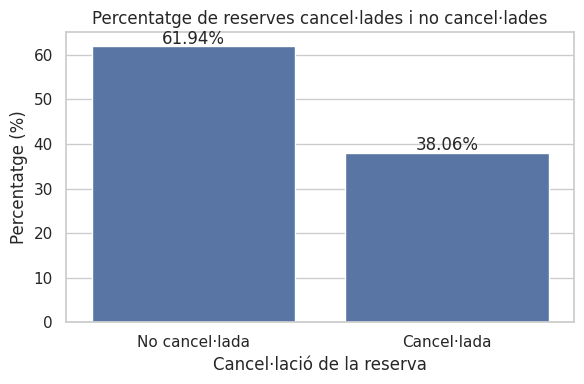

In [ ]:
# ==========================================================
# GRÀFIC DE PERCENTATGES DE LA VARIABLE OBJECTIU
# ==========================================================

target_pct_df = (
    df[target]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .reset_index()
)

target_pct_df.columns = [target, "percentatge"]

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=target_pct_df, x=target, y="percentatge")

plt.title("Percentatge de reserves cancel·lades i no cancel·lades")
plt.xlabel("Cancel·lació de la reserva")
plt.ylabel("Percentatge (%)")
plt.xticks([0, 1], ["No cancel·lada", "Cancel·lada"])

# Afegir etiqueta de percentatge a cada barra
for i, v in enumerate(target_pct_df["percentatge"]):
    ax.text(i, v + 0.5, f"{v:.2f}%", ha="center")

plt.tight_layout()
plt.show()

## 3. Anàlisi de variables numèriques

En aquesta secció s'estudia la distribució de les principals variables numèriques del conjunt de dades, amb especial atenció a la seva dispersió, asimetria i possibles valors extrems.

In [ ]:
# ==========================================================
# RESUM DESCRIPTIU DE VARIABLES NUMÈRIQUES
# ==========================================================

numeric_cols = [
    "lead_time",
    "adr",
    "total_nights",
    "total_guests",
    "booking_changes",
    "days_in_waiting_list",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

numeric_summary = df[numeric_cols].describe().T
numeric_summary["median"] = df[numeric_cols].median()
numeric_summary["missing_pct"] = (df[numeric_cols].isna().mean() * 100).round(2)

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,median,missing_pct
lead_time,5000.0,105.70740,108.574166,0.0,18.0000,70.00,164.0,629.0,70.00,0.0
adr,5000.0,100.80218,47.568669,0.0,68.1225,92.75,125.0,451.5,92.75,0.0
total_nights,5000.0,3.37200,2.461794,0.0,2.0000,3.00,4.0,27.0,3.00,0.0
total_guests,5000.0,1.97100,0.641125,0.0,2.0000,2.00,2.0,5.0,2.00,0.0
booking_changes,5000.0,0.21000,0.683223,0.0,0.0000,0.00,0.0,14.0,0.00,0.0
days_in_waiting_list,5000.0,2.51700,19.989318,0.0,0.0000,0.00,0.0,391.0,0.00,0.0
previous_cancellations,5000.0,0.09160,0.873248,0.0,0.0000,0.00,0.0,26.0,0.00,0.0
previous_bookings_not_canceled,5000.0,0.13640,1.420915,0.0,0.0000,0.00,0.0,54.0,0.00,0.0
required_car_parking_spaces,5000.0,0.05940,0.236395,0.0,0.0000,0.00,0.0,1.0,0.00,0.0
total_of_special_requests,5000.0,0.56440,0.798486,0.0,0.0000,0.00,1.0,5.0,0.00,0.0


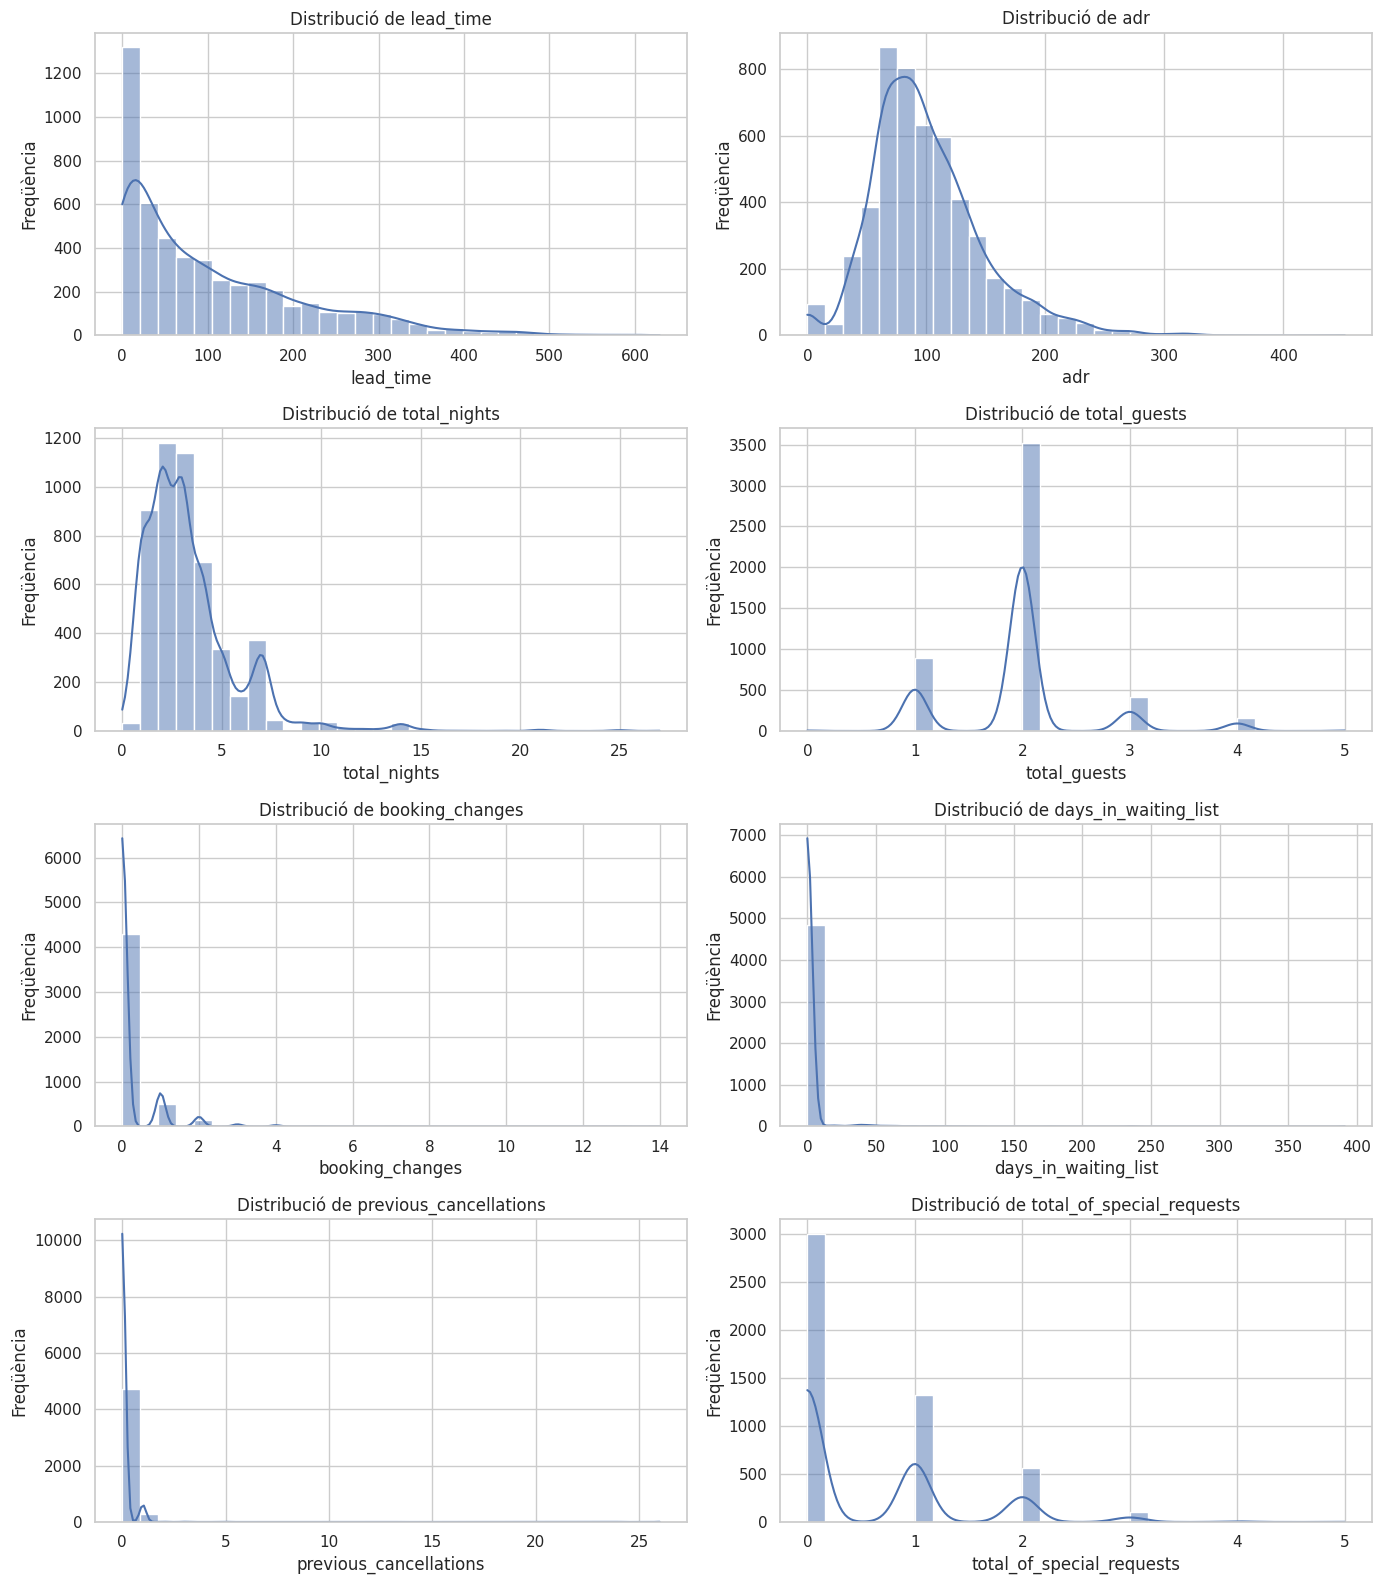

In [ ]:
# ==========================================================
# HISTOGRAMES DE LES VARIABLES NUMÈRIQUES PRINCIPALS
# ==========================================================

plot_cols = [
    "lead_time",
    "adr",
    "total_nights",
    "total_guests",
    "booking_changes",
    "days_in_waiting_list",
    "previous_cancellations",
    "total_of_special_requests"
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(f"Distribució de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Freqüència")

plt.tight_layout()
plt.show()

## 4. Anàlisi de variables categòriques

S'analitza la distribució de les principals variables categòriques per tal d'identificar quines categories són més freqüents i quina estructura presenta el conjunt de dades des d'un punt de vista qualitatiu.

In [ ]:
# ==========================================================
# FUNCIÓ AUXILIAR PER OBTENIR LES CATEGORIES MÉS FREQÜENTS
# ==========================================================

def top_category_table(frame, col, n=10):
    counts = frame[col].fillna("Missing").value_counts(dropna=False).head(n)
    pct = (counts / len(frame) * 100).round(2)
    return pd.DataFrame({"count": counts, "pct": pct})

In [ ]:
# ==========================================================
# TAULES DE FREQÜÈNCIES PER A VARIABLES CATEGÒRIQUES CLAU
# ==========================================================

display(top_category_table(df, "country", n=12))
display(top_category_table(df, "market_segment", n=10))
display(top_category_table(df, "distribution_channel", n=10))

,count,pct
country,,
PRT,2066,41.32
GBR,504,10.08
FRA,440,8.80
ESP,364,7.28
DEU,284,5.68
ITA,168,3.36
IRL,138,2.76
BRA,96,1.92
USA,89,1.78


,count,pct
market_segment,,
Online TA,2334,46.68
Offline TA/TO,1033,20.66
Groups,858,17.16
Direct,522,10.44
Corporate,214,4.28
Complementary,30,0.60
Aviation,9,0.18


,count,pct
distribution_channel,,
TA/TO,4082,81.64
Direct,628,12.56
Corporate,277,5.54
GDS,13,0.26


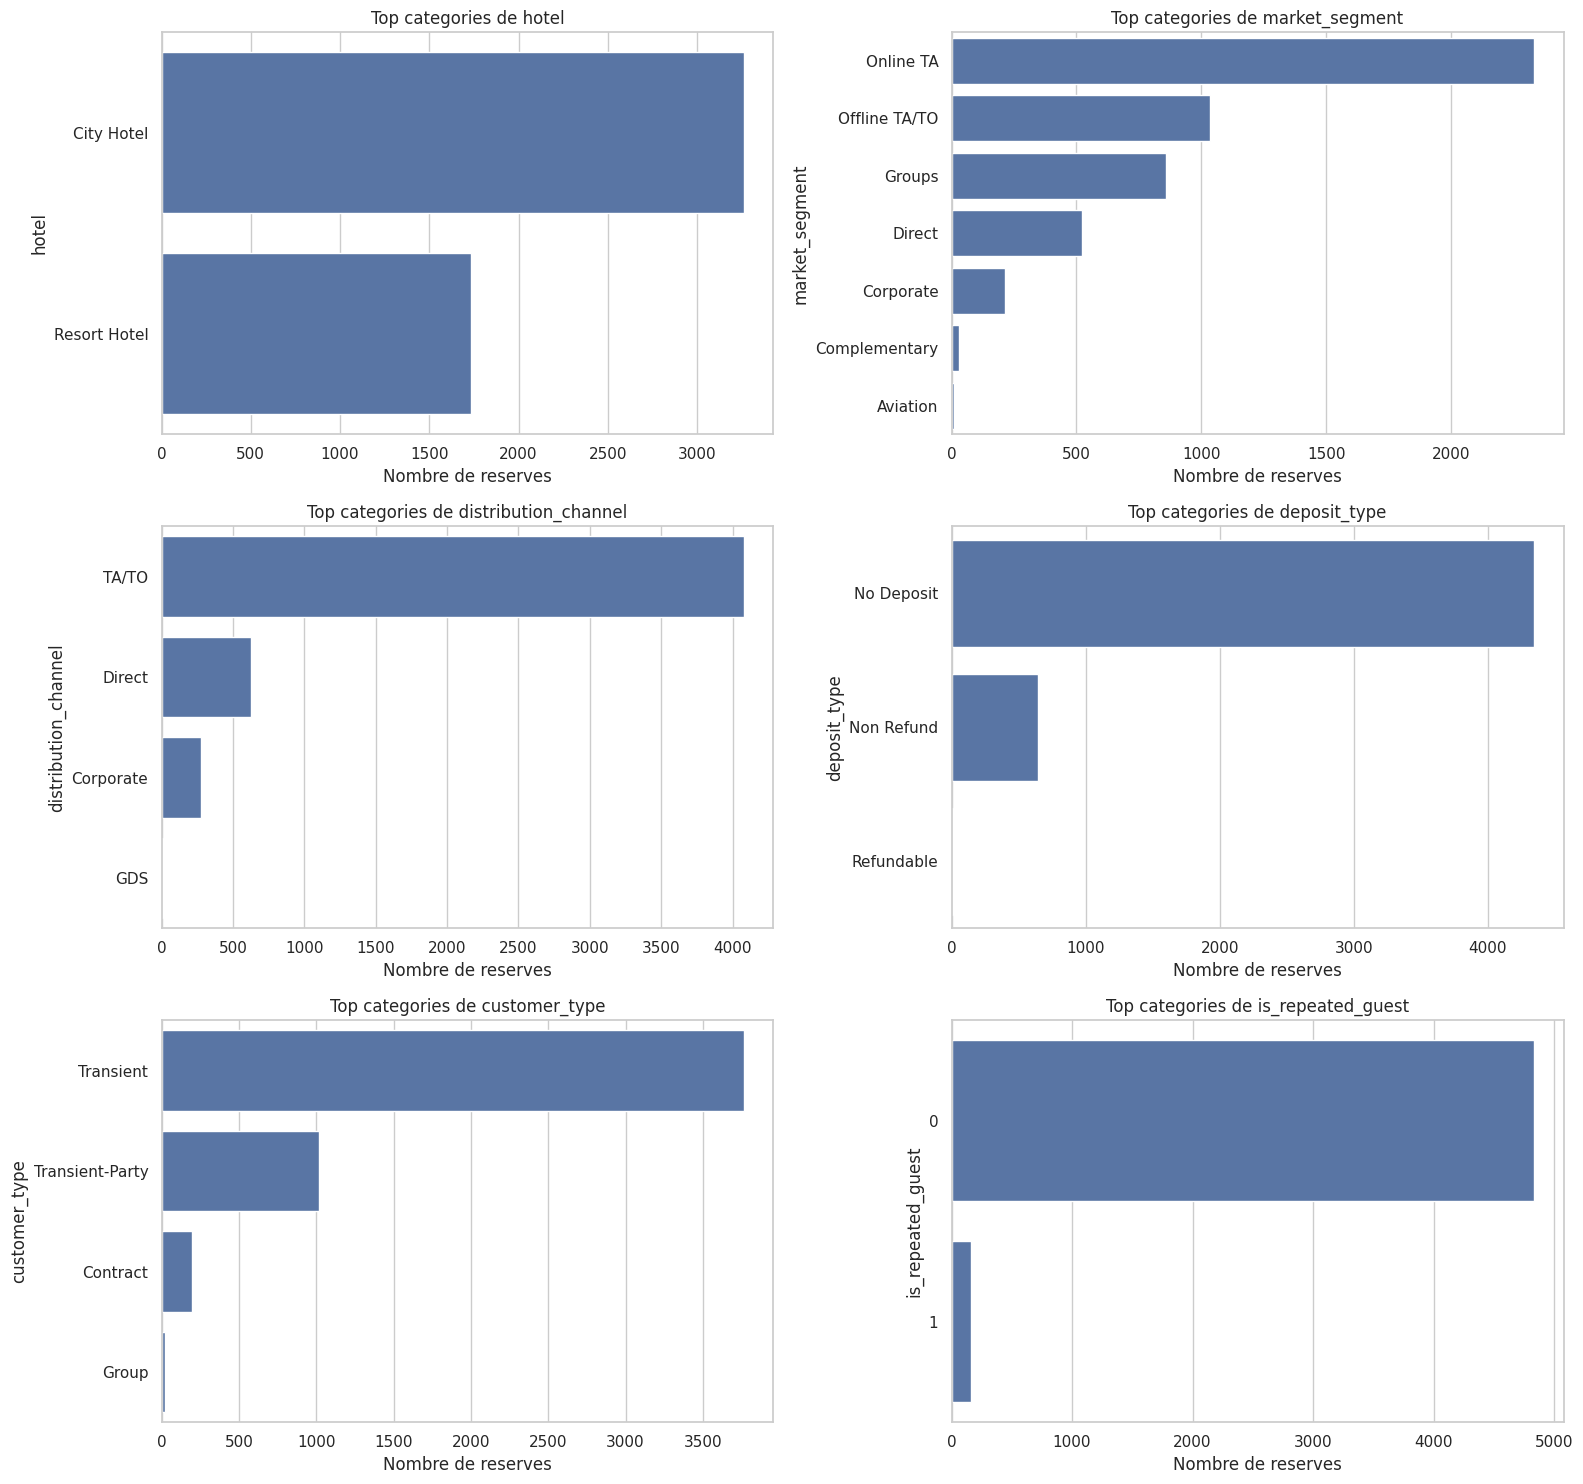

In [ ]:
# ==========================================================
# DISTRIBUCIÓ DE VARIABLES CATEGÒRIQUES SELECCIONADES
# ==========================================================

cat_cols_to_plot = [
    "hotel",
    "market_segment",
    "distribution_channel",
    "deposit_type",
    "customer_type",
    "is_repeated_guest",
    "assigned_room_type"
]

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols_to_plot):
    temp = df.copy()
    temp[col] = temp[col].fillna("Missing")
    order = temp[col].value_counts().index[:10]
    sns.countplot(data=temp, y=col, order=order, ax=ax)
    ax.set_title(f"Top categories de {col}")
    ax.set_xlabel("Nombre de reserves")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

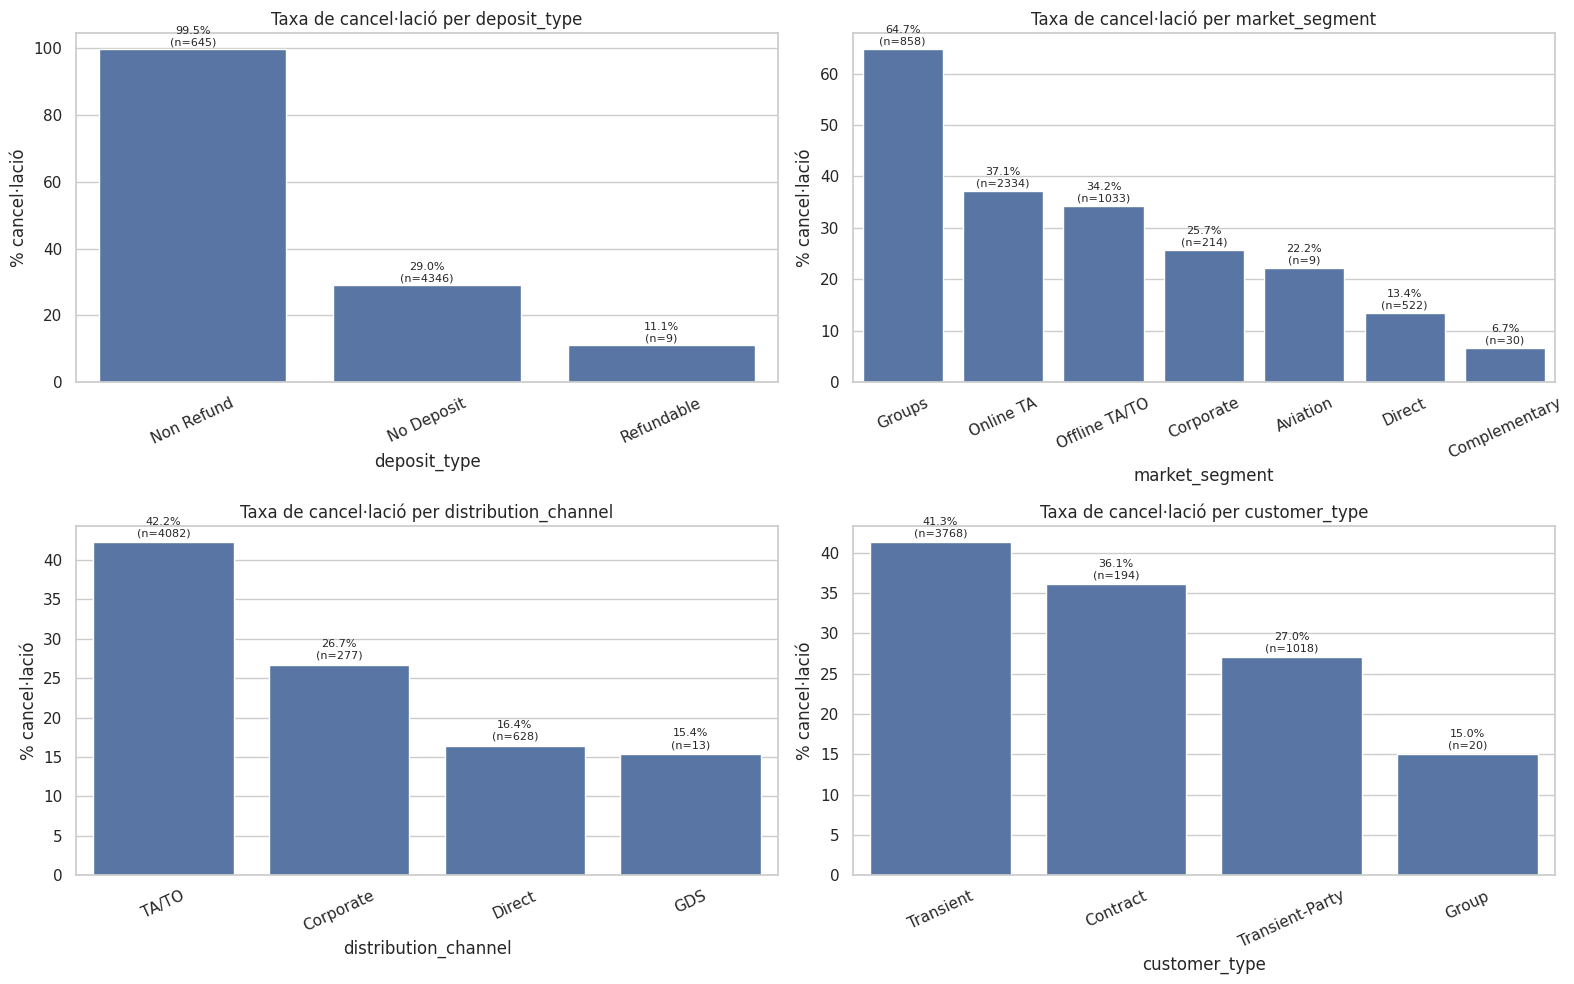

In [ ]:
# ==========================================================
# TAXA DE CANCEL·LACIÓ PER VARIABLES CATEGÒRIQUES CLAU
# ==========================================================

cat_cancel_cols = ["deposit_type", "market_segment", "distribution_channel", "customer_type"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cancel_cols):
    cancel_rate = (
        df.groupby(col, observed=False)["is_canceled"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "cancel_rate", "count": "n"})
        .sort_values("cancel_rate", ascending=False)
        .reset_index()
    )
    cancel_rate["cancel_rate_pct"] = (cancel_rate["cancel_rate"] * 100).round(2)

    bars = sns.barplot(data=cancel_rate, x=col, y="cancel_rate_pct", ax=ax)
    ax.set_title(f"Taxa de cancel·lació per {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("% cancel·lació")
    ax.tick_params(axis="x", rotation=25)

    for i, row in cancel_rate.iterrows():
        ax.text(i, row["cancel_rate_pct"] + 0.5, f"{row['cancel_rate_pct']:.1f}%\n(n={row['n']})",
                ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## 5. Relacions entre variables i cancel·lació

En aquesta secció s'analitza la relació entre diferents variables explicatives i la cancel·lació de les reserves, amb l'objectiu d'identificar patrons rellevants per al desenvolupament posterior dels models predictius.

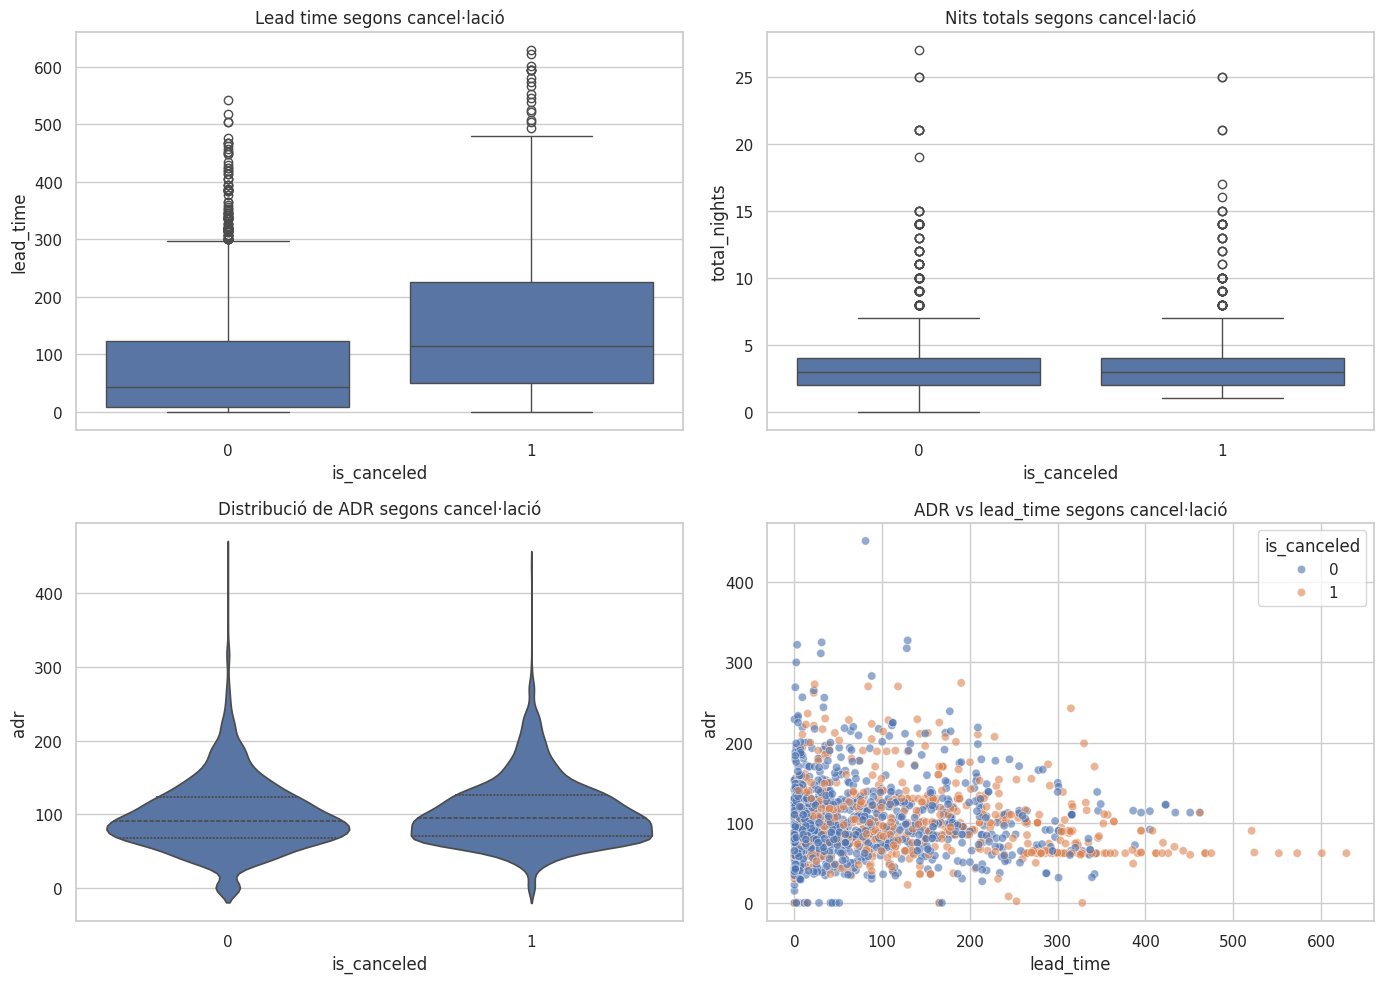

In [ ]:
# ==========================================================
# RELACIÓ ENTRE VARIABLES NUMÈRIQUES I LA VARIABLE OBJECTIU
# ==========================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x="is_canceled", y="lead_time", ax=axes[0, 0])
axes[0, 0].set_title("Lead time segons cancel·lació")

sns.boxplot(data=df, x="is_canceled", y="total_nights", ax=axes[0, 1])
axes[0, 1].set_title("Nits totals segons cancel·lació")

sns.violinplot(data=df, x="is_canceled", y="adr", inner="quartile", ax=axes[1, 0])
axes[1, 0].set_title("Distribució de ADR segons cancel·lació")

sns.scatterplot(
    data=df.sample(min(len(df), 1500), random_state=42),
    x="lead_time",
    y="adr",
    hue="is_canceled",
    alpha=0.6,
    ax=axes[1, 1]
)
axes[1, 1].set_title("ADR vs lead_time segons cancel·lació")

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# RESUM NUMÈRIC DE VARIABLES PRINCIPALS SEGONS CANCEL·LACIÓ
# ==========================================================

num_vs_target = [
    "lead_time",
    "adr",
    "total_nights",
    "total_guests",
    "total_of_special_requests"
]

for col in num_vs_target:
    print(f"\nResum de {col} per is_canceled:")
    display(df.groupby("is_canceled")[col].agg(["mean", "median", "std", "min", "max"]))


Resum de lead_time per is_canceled:


,mean,median,std,min,max
is_canceled,,,,,
0,79.155634,44.0,90.761153,0,542
1,148.918550,115.0,120.657436,0,629



Resum de adr per is_canceled:


,mean,median,std,min,max
is_canceled,,,,,
0,98.940139,90.93,48.595058,0.0,451.5
1,103.832522,95.00,45.699807,0.0,437.0



Resum de total_nights per is_canceled:


,mean,median,std,min,max
is_canceled,,,,,
0,3.378108,3.0,2.559387,0,27
1,3.362060,3.0,2.294732,1,25



Resum de total_guests per is_canceled:


,mean,median,std,min,max
is_canceled,,,,,
0,1.953503,2.0,0.656734,0.0,5.0
1,1.999475,2.0,0.613980,0.0,5.0



Resum de total_of_special_requests per is_canceled:


,mean,median,std,min,max
is_canceled,,,,,
0,0.721020,1.0,0.851159,0,5
1,0.309511,0.0,0.625727,0,3


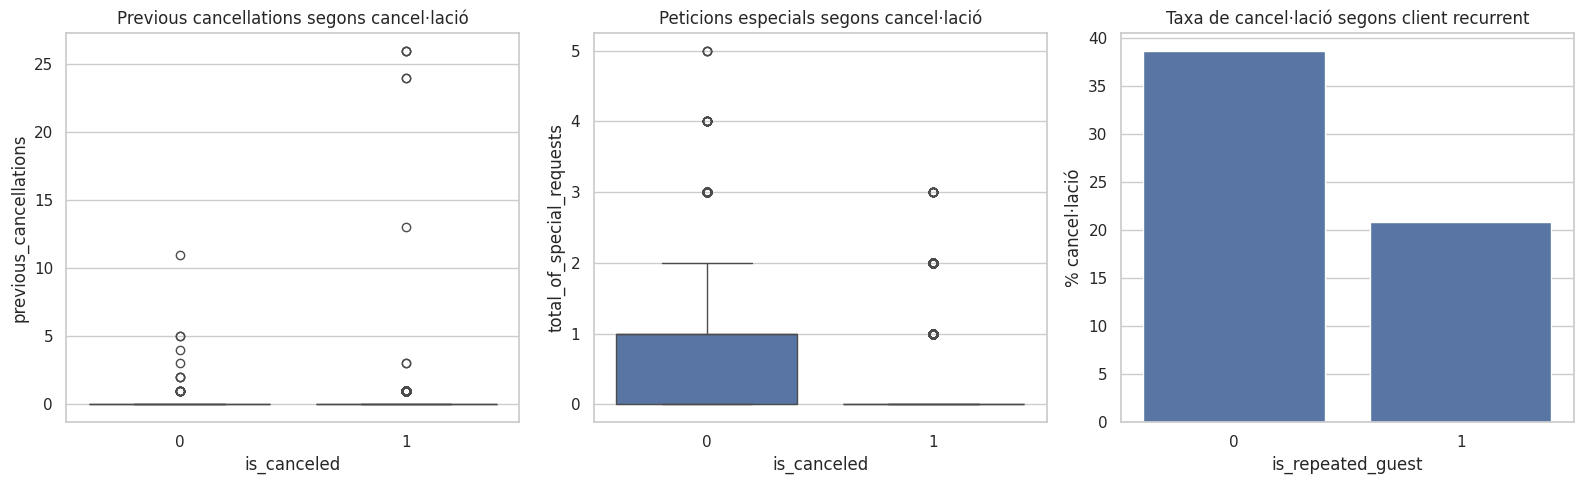

In [ ]:
# ==========================================================
# VARIABLES ADDICIONALS RELLEVANTS PER A LA CANCEL·LACIÓ
# ==========================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x="is_canceled", y="previous_cancellations", ax=axes[0])
axes[0].set_title("Previous cancellations segons cancel·lació")

sns.boxplot(data=df, x="is_canceled", y="total_of_special_requests", ax=axes[1])
axes[1].set_title("Peticions especials segons cancel·lació")

sns.barplot(
    x=(df.groupby("is_repeated_guest")["is_canceled"].mean() * 100).index,
    y=(df.groupby("is_repeated_guest")["is_canceled"].mean() * 100).values,
    ax=axes[2]
)
axes[2].set_title("Taxa de cancel·lació segons client recurrent")
axes[2].set_xlabel("is_repeated_guest")
axes[2].set_ylabel("% cancel·lació")

plt.tight_layout()
plt.show()

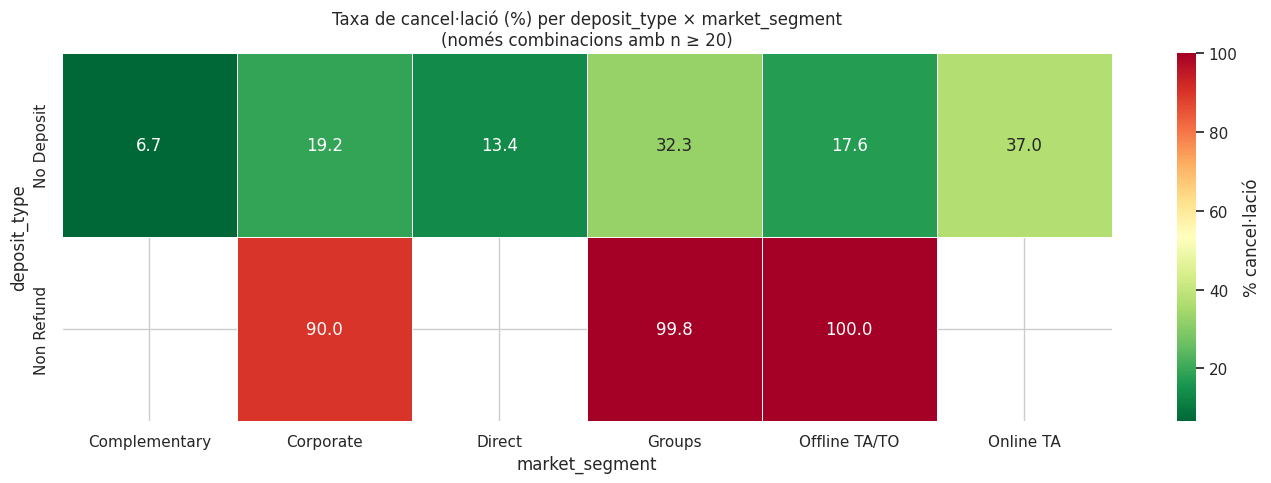


Tabla detallada (n ≥ 20):


,deposit_type,market_segment,cancel_rate,n,cancel_rate_pct
9,Non Refund,Offline TA/TO,1.000000,208,100.00
8,Non Refund,Groups,0.997590,415,99.76
7,Non Refund,Corporate,0.900000,20,90.00
6,No Deposit,Online TA,0.370227,2331,37.02
4,No Deposit,Groups,0.323394,436,32.34
2,No Deposit,Corporate,0.191710,193,19.17
5,No Deposit,Offline TA/TO,0.175758,825,17.58
3,No Deposit,Direct,0.134100,522,13.41
1,No Deposit,Complementary,0.066667,30,6.67


In [ ]:
# ==========================================================
# INTERACCIÓ deposit_type × market_segment
# ==========================================================

interaction = (
    df.groupby(["deposit_type", "market_segment"], observed=False)["is_canceled"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "cancel_rate", "count": "n"})
    .reset_index()
)

interaction["cancel_rate_pct"] = (interaction["cancel_rate"] * 100).round(2)

# Només mostrem combinacions amb prou volum per ser representatives
interaction_filtered = interaction[interaction["n"] >= 20].copy()

pivot = interaction_filtered.pivot(index="deposit_type", columns="market_segment", values="cancel_rate_pct")

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn_r", linewidths=0.5,
            cbar_kws={"label": "% cancel·lació"})
plt.title("Taxa de cancel·lació (%) per deposit_type × market_segment\n(només combinacions amb n ≥ 20)")
plt.tight_layout()
plt.show()

print("\nTabla detallada (n ≥ 20):")
display(interaction_filtered.sort_values("cancel_rate_pct", ascending=False).head(15))

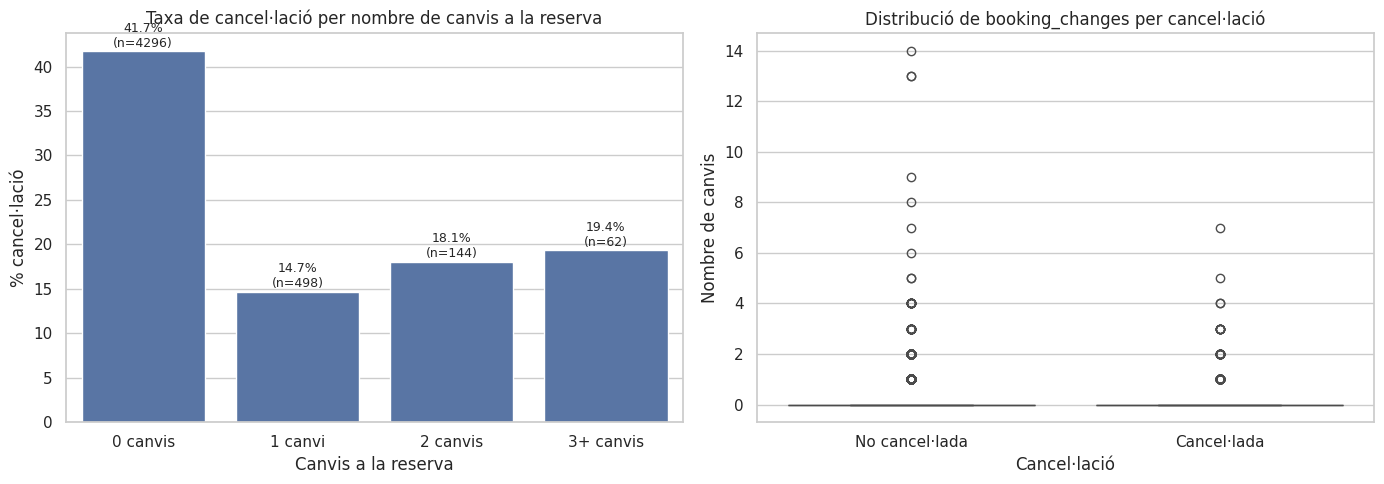


Resum estadístic de booking_changes per is_canceled:


,mean,median,std
is_canceled,,,
0,0.284469,0.0,0.793299
1,0.088807,0.0,0.422794


In [ ]:
# ==========================================================
# BOOKING CHANGES VS CANCEL·LACIÓ
# ==========================================================

# Agrupem en categories per llegibilitat
df["booking_changes_grp"] = pd.cut(
    df["booking_changes"],
    bins=[-1, 0, 1, 2, 100],
    labels=["0 canvis", "1 canvi", "2 canvis", "3+ canvis"]
)

changes_cancel = (
    df.groupby("booking_changes_grp", observed=False)["is_canceled"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "cancel_rate", "count": "n"})
    .reset_index()
)
changes_cancel["cancel_rate_pct"] = (changes_cancel["cancel_rate"] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=changes_cancel, x="booking_changes_grp", y="cancel_rate_pct", ax=axes[0])
axes[0].set_title("Taxa de cancel·lació per nombre de canvis a la reserva")
axes[0].set_xlabel("Canvis a la reserva")
axes[0].set_ylabel("% cancel·lació")
for i, row in changes_cancel.iterrows():
    axes[0].text(i, row["cancel_rate_pct"] + 0.5,
                 f"{row['cancel_rate_pct']:.1f}%\n(n={row['n']})",
                 ha="center", fontsize=9)

sns.boxplot(data=df, x="is_canceled", y="booking_changes", ax=axes[1])
axes[1].set_title("Distribució de booking_changes per cancel·lació")
axes[1].set_xlabel("Cancel·lació")
axes[1].set_ylabel("Nombre de canvis")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["No cancel·lada", "Cancel·lada"])

plt.tight_layout()
plt.show()

print("\nResum estadístic de booking_changes per is_canceled:")
display(df.groupby("is_canceled")["booking_changes"].agg(["mean", "median", "std"]))

Distribució de days_in_waiting_list:


,days_in_waiting_list
count,5000.000000
mean,2.517000
std,19.989318
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,391.000000



Reserves amb llista d'espera > 0: 159 (3.2%)


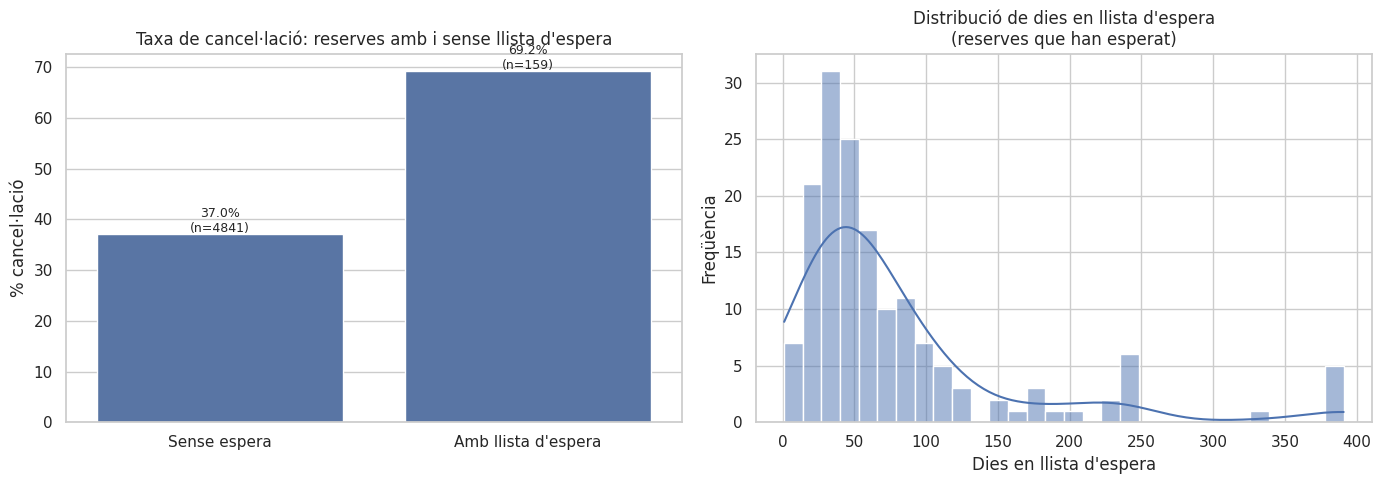

In [ ]:
# ==========================================================
# DAYS IN WAITING LIST VS CANCEL·LACIÓ
# ==========================================================

# Estadístiques bàsiques
print("Distribució de days_in_waiting_list:")
display(df["days_in_waiting_list"].describe())
print(f"\nReserves amb llista d'espera > 0: {(df['days_in_waiting_list'] > 0).sum()} "
      f"({(df['days_in_waiting_list'] > 0).mean()*100:.1f}%)")

# Comparativa de taxa de cancel·lació
df["in_waiting_list"] = (df["days_in_waiting_list"] > 0).astype(int)

waiting_cancel = (
    df.groupby("in_waiting_list")["is_canceled"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "cancel_rate", "count": "n"})
    .reset_index()
)
waiting_cancel["cancel_rate_pct"] = (waiting_cancel["cancel_rate"] * 100).round(2)
waiting_cancel["in_waiting_list"] = waiting_cancel["in_waiting_list"].map({0: "Sense espera", 1: "Amb llista d'espera"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=waiting_cancel, x="in_waiting_list", y="cancel_rate_pct", ax=axes[0])
axes[0].set_title("Taxa de cancel·lació: reserves amb i sense llista d'espera")
axes[0].set_xlabel("")
axes[0].set_ylabel("% cancel·lació")
for i, row in waiting_cancel.iterrows():
    axes[0].text(i, row["cancel_rate_pct"] + 0.5,
                 f"{row['cancel_rate_pct']:.1f}%\n(n={row['n']})", ha="center", fontsize=9)

# Distribució dels dies d'espera (només els que han esperat)
waited = df[df["days_in_waiting_list"] > 0]["days_in_waiting_list"]
sns.histplot(waited, bins=30, kde=True, ax=axes[1])
axes[1].set_title("Distribució de dies en llista d'espera\n(reserves que han esperat)")
axes[1].set_xlabel("Dies en llista d'espera")
axes[1].set_ylabel("Freqüència")

plt.tight_layout()
plt.show()

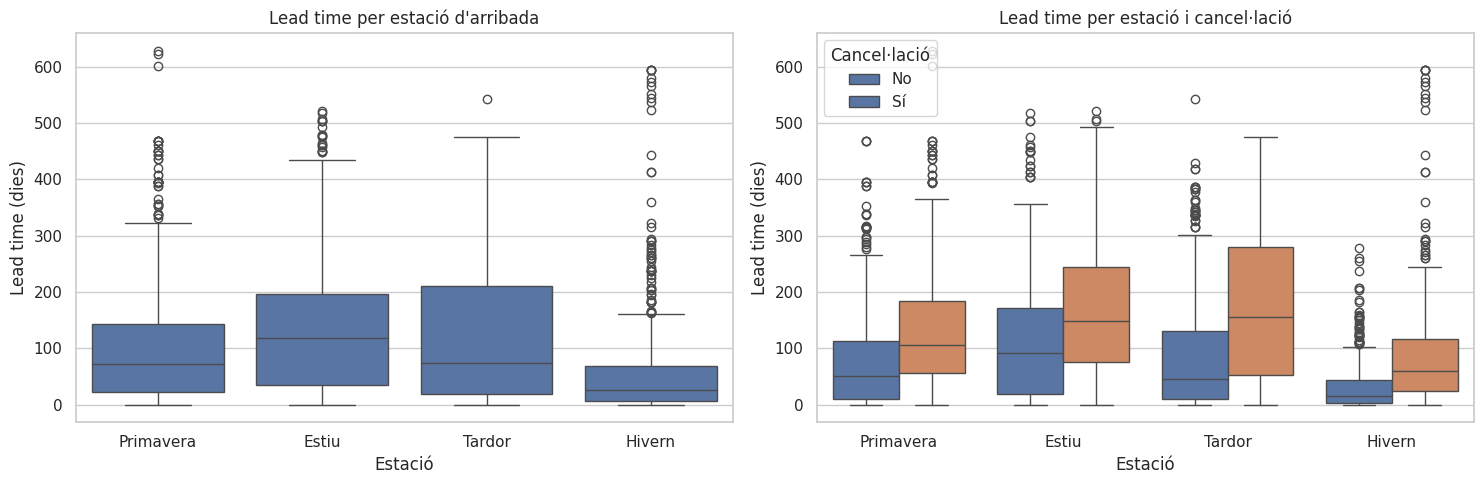


Lead time mitjà per estació:


,mean,median,count
season,,,
Primavera,98.009468,72.0,1373
Estiu,131.953115,119.0,1557
Tardor,118.978796,73.0,1179
Hivern,54.144781,25.0,891


In [ ]:
# ==========================================================
# LEAD TIME PER ESTACIÓ DE L'ANY
# ==========================================================

season_map = {
    "December": "Hivern", "January": "Hivern", "February": "Hivern",
    "March": "Primavera", "April": "Primavera", "May": "Primavera",
    "June": "Estiu", "July": "Estiu", "August": "Estiu",
    "September": "Tardor", "October": "Tardor", "November": "Tardor"
}

df["season"] = df["arrival_date_month"].astype(str).map(season_map)
season_order = ["Primavera", "Estiu", "Tardor", "Hivern"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, x="season", y="lead_time", order=season_order, ax=axes[0])
axes[0].set_title("Lead time per estació d'arribada")
axes[0].set_xlabel("Estació")
axes[0].set_ylabel("Lead time (dies)")

sns.boxplot(data=df, x="season", y="lead_time", hue="is_canceled",
            order=season_order, ax=axes[1])
axes[1].set_title("Lead time per estació i cancel·lació")
axes[1].set_xlabel("Estació")
axes[1].set_ylabel("Lead time (dies)")
axes[1].legend(title="Cancel·lació", labels=["No", "Sí"])

plt.tight_layout()
plt.show()

print("\nLead time mitjà per estació:")
display(df.groupby("season")["lead_time"].agg(["mean", "median", "count"]).loc[season_order])

In [ ]:
# ==========================================================
# TAXA DE CANCEL·LACIÓ PER TIPUS DE HOTEL
# ==========================================================

hotel_cancel = (
    df.groupby("hotel", observed=False)["is_canceled"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "cancel_rate", "count": "n"})
)

hotel_cancel["cancel_rate"] = (hotel_cancel["cancel_rate"] * 100).round(2)
display(hotel_cancel)

,cancel_rate,n
hotel,,
City Hotel,43.38,3264
Resort Hotel,28.05,1736


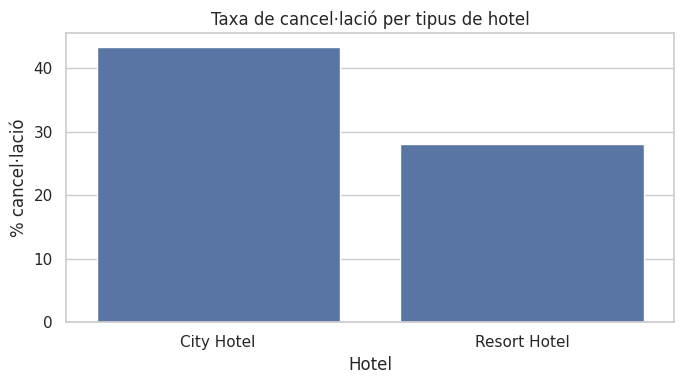

In [ ]:
# Gràfic de la taxa de cancel·lació per tipus de hotel
hotel_cancel_plot = df.groupby("hotel")["is_canceled"].mean().mul(100).reset_index()

plt.figure(figsize=(7, 4))
sns.barplot(data=hotel_cancel_plot, x="hotel", y="is_canceled")
plt.title("Taxa de cancel·lació per tipus de hotel")
plt.xlabel("Hotel")
plt.ylabel("% cancel·lació")
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# TAXA DE CANCEL·LACIÓ ALS PAÏSOS AMB MÉS RESERVES
# ==========================================================

top_countries = df["country"].fillna("Missing").value_counts().head(12).index
country_df = df[df["country"].fillna("Missing").isin(top_countries)].copy()

country_cancel = (
    country_df.groupby("country", observed=False)["is_canceled"]
    .agg(["mean", "count"])
    .sort_values("count", ascending=False)
)

country_cancel["cancel_rate_%"] = (country_cancel["mean"] * 100).round(2)
display(country_cancel[["count", "cancel_rate_%"]])

,count,cancel_rate_%
country,,
PRT,2066,58.86
GBR,504,18.25
FRA,440,17.27
ESP,364,23.08
DEU,284,16.20
ITA,168,44.64
IRL,138,26.81
BRA,96,40.62
USA,89,21.35


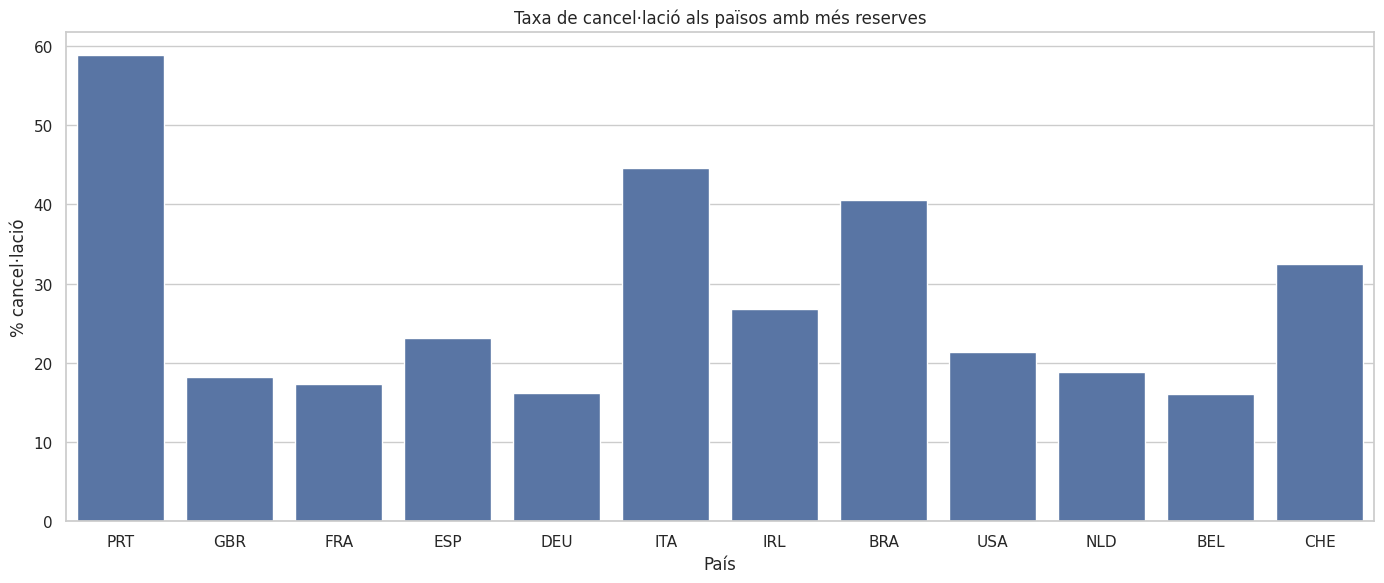

In [ ]:
# Gràfic de taxa de cancel·lació per país
plt.figure(figsize=(14, 6))
sns.barplot(
    data=country_cancel.reset_index(),
    x="country",
    y="cancel_rate_%"
)
plt.title("Taxa de cancel·lació als països amb més reserves")
plt.xlabel("País")
plt.ylabel("% cancel·lació")
plt.tight_layout()
plt.show()

## 6. Anàlisi temporal

S'analitza l'evolució de les reserves i del valor mitjà de l'ADR segons el mes d'arribada i l'any, per tal d'identificar possibles patrons estacionals.

Cal interpretar aquesta anàlisi temporal amb prudència, ja que el conjunt de dades utilitzat correspon a una mostra del total de reserves i la cobertura temporal pot no ser homogènia entre els diferents anys.

In [ ]:
# ==========================================================
# EVOLUCIÓ TEMPORAL DE RESERVES I ADR
# ==========================================================

monthly_bookings = (
    df.groupby(["arrival_date_year", "arrival_date_month"], observed=False)
    .size()
    .reset_index(name="bookings")
)

monthly_adr = (
    df.groupby(["arrival_date_year", "arrival_date_month"], observed=False)["adr"]
    .mean()
    .reset_index(name="avg_adr")
)

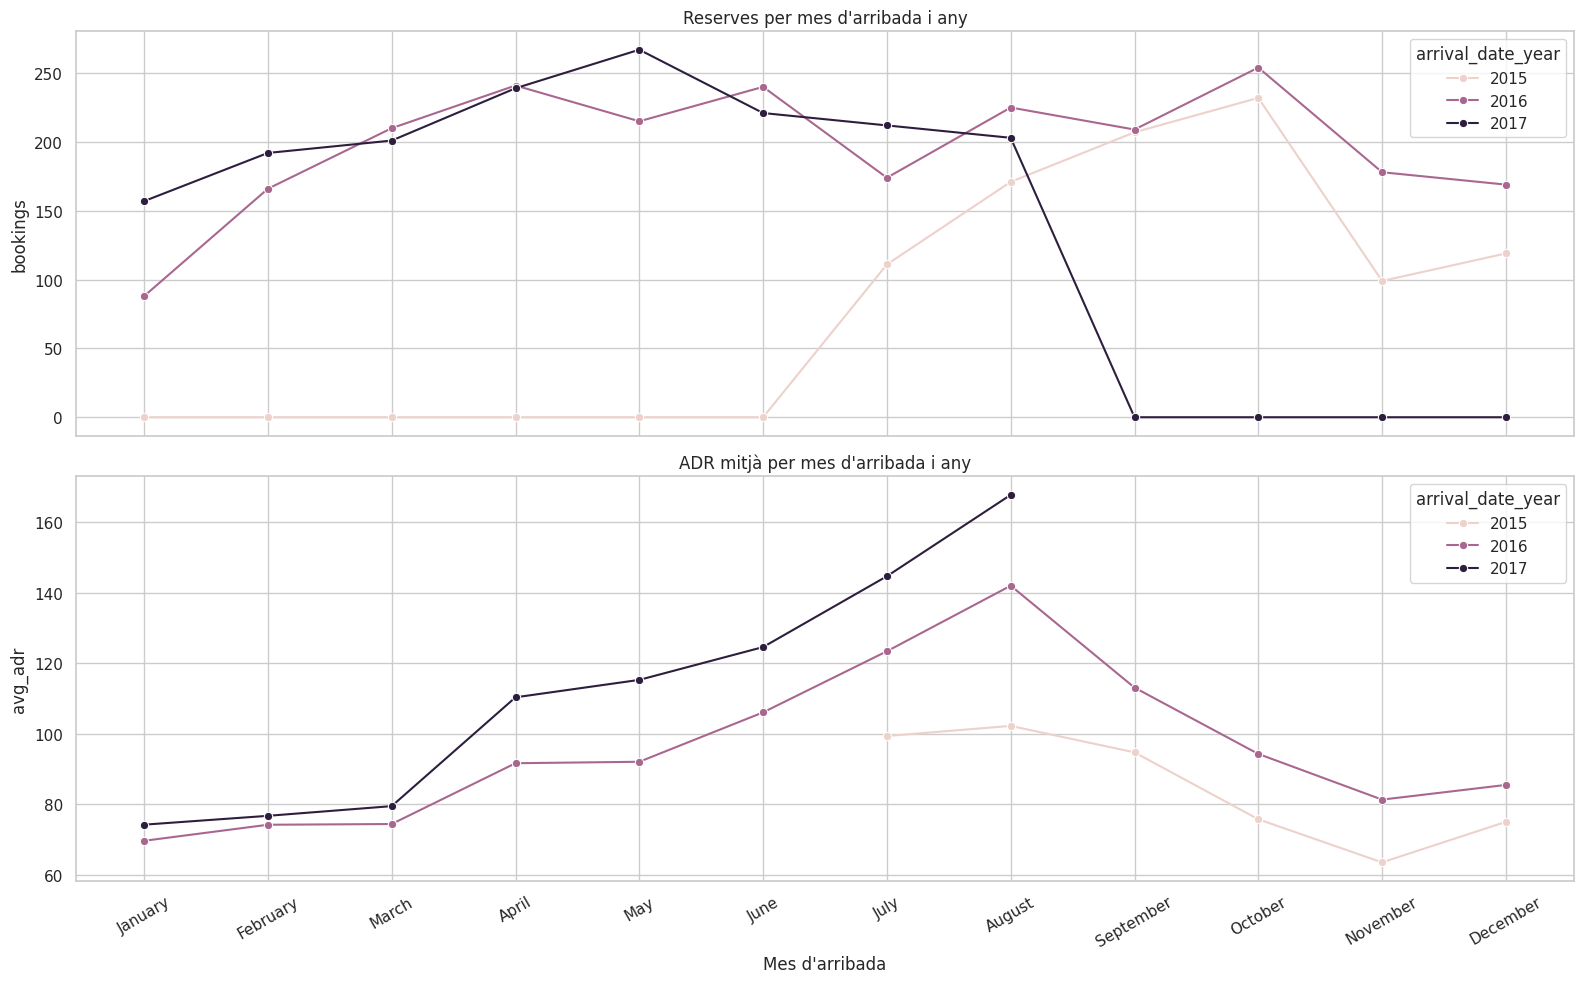

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

sns.lineplot(
    data=monthly_bookings,
    x="arrival_date_month",
    y="bookings",
    hue="arrival_date_year",
    marker="o",
    ax=axes[0]
)
axes[0].set_title("Reserves per mes d'arribada i any")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

sns.lineplot(
    data=monthly_adr,
    x="arrival_date_month",
    y="avg_adr",
    hue="arrival_date_year",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("ADR mitjà per mes d'arribada i any")
axes[1].set_xlabel("Mes d'arribada")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 7. Matriu de correlació de variables numèriques seleccionades

Finalment, s'analitza la correlació entre un conjunt reduït de variables numèriques rellevants per identificar possibles relacions lineals i anticipar problemes de redundància.

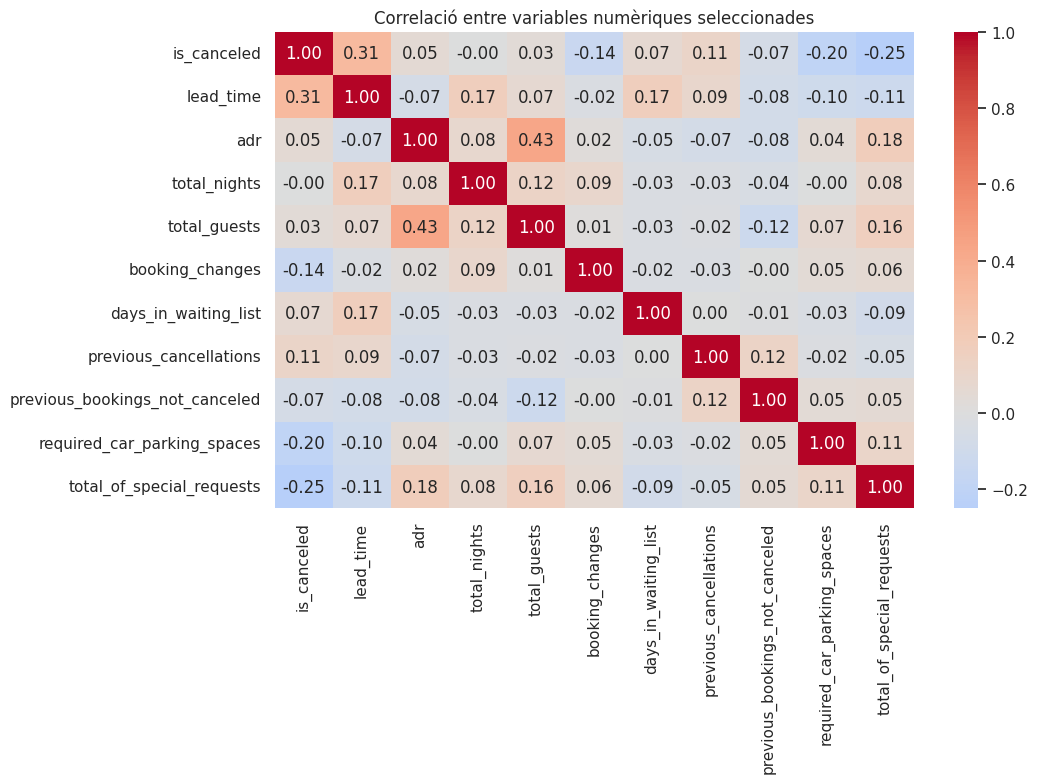

In [ ]:
# ==========================================================
# CORRELACIÓ ENTRE VARIABLES NUMÈRIQUES RELLEVANTS
# ==========================================================

corr_cols = [
    "is_canceled",
    "lead_time",
    "adr",
    "total_nights",
    "total_guests",
    "booking_changes",
    "days_in_waiting_list",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlació entre variables numèriques seleccionades")
plt.tight_layout()
plt.show()

## 8. Principals insights

A partir de l'anàlisi exploratòria realitzada, es poden destacar diverses conclusions preliminars. En primer lloc, la variable `lead_time` mostra una relació clara amb la cancel·lació, ja que les reserves cancel·lades tendeixen a presentar una antelació superior. En segon lloc, el tipus de dipòsit sembla ser una de les variables més discriminants, amb diferències molt marcades en la taxa de cancel·lació entre categories. També s'observen diferències rellevants segons el segment de mercat, el canal de distribució i el tipus de client.

Pel que fa a les variables econòmiques, l'ADR presenta dispersió i alguns valors extrems, però també diferències moderades entre reserves cancel·lades i no cancel·lades. Finalment, l'anàlisi temporal suggereix l'existència de patrons estacionals tant en el volum de reserves com en el valor mitjà de l'ADR, tot i que aquests resultats s'han d'interpretar amb prudència atesa la naturalesa mostral del conjunt de dades.

Aquestes observacions permeten identificar quines variables poden ser més útils en la fase posterior de modelització.

In [ ]:
# ==========================================================
# RESUM AUTOMÀTIC D'INSIGHTS CLAU
# ==========================================================

insights = {
    "taxa_global_cancelacio_%": round(df["is_canceled"].mean() * 100, 2),
    "adr_mitja": round(df["adr"].mean(), 2),
    "mediana_lead_time": round(df["lead_time"].median(), 2),
    "pais_mes_frequent": df["country"].mode(dropna=True)[0],
    "market_segment_mes_frequent": df["market_segment"].mode(dropna=True)[0],
    "hotel_amb_mes_cancelacio": df.groupby("hotel", observed=False)["is_canceled"].mean().idxmax(),
    "deposit_type_amb_mes_cancelacio": df.groupby("deposit_type", observed=False)["is_canceled"].mean().idxmax()
}

display(pd.Series(insights, name="valor").to_frame())

,valor
taxa_global_cancelacio_%,38.06
adr_mitja,100.8
mediana_lead_time,70.0
pais_mes_frequent,PRT
market_segment_mes_frequent,Online TA
hotel_amb_mes_cancelacio,City Hotel
deposit_type_amb_mes_cancelacio,Non Refund


In [ ]:
# ==========================================================
# INSIGHTS ADDICIONALS
# ==========================================================

insights_addicionals = {}

# Efecte de booking_changes
no_changes_cancel = df[df["booking_changes"] == 0]["is_canceled"].mean() * 100
with_changes_cancel = df[df["booking_changes"] > 0]["is_canceled"].mean() * 100
insights_addicionals["cancel_rate_sense_canvis_%"] = round(no_changes_cancel, 2)
insights_addicionals["cancel_rate_amb_canvis_%"] = round(with_changes_cancel, 2)

# Efecte de waiting list
no_wait_cancel = df[df["days_in_waiting_list"] == 0]["is_canceled"].mean() * 100
wait_cancel = df[df["days_in_waiting_list"] > 0]["is_canceled"].mean() * 100
insights_addicionals["cancel_rate_sense_espera_%"] = round(no_wait_cancel, 2)
insights_addicionals["cancel_rate_amb_espera_%"] = round(wait_cancel, 2)

display(pd.Series(insights_addicionals, name="valor").to_frame())

,valor
cancel_rate_sense_canvis_%,41.71
cancel_rate_amb_canvis_%,15.77
cancel_rate_sense_espera_%,37.04
cancel_rate_amb_espera_%,69.18


## 9. Implicacions per al preprocessament

Els resultats de l’EDA suggereixen diverses decisions rellevants per a la fase de preprocessament. En primer lloc, la presència de valors absents en variables com `agent`, `company` i `country` fa necessari definir una estratègia de tractament específica per a cadascuna d’elles. En segon lloc, la forta asimetria observada en variables com `lead_time`, `days_in_waiting_list` o `previous_cancellations` indica la presència de distribucions no normals i de possibles valors extrems, fet que recomana utilitzar transformacions robustes o escales adequades segons el model emprat.

A més, l’anàlisi posa de manifest que algunes variables tenen una relació clara amb la cancel·lació, com ara `deposit_type`, `market_segment`, `distribution_channel`, `lead_time`, `previous_cancellations` o `total_of_special_requests`, de manera que es consideren candidates rellevants per a la modelització posterior. Finalment, variables com `reservation_status` i `reservation_status_date` hauran de ser revisades amb especial atenció, ja que poden contenir informació posterior al moment de la reserva i introduir problemes de *data leakage*.

In [ ]:
# ==========================================================
# VARIABLES QUE CONVÉ REVISAR A LA FASE DE PREPROCESSAMENT
# ==========================================================

variables_a_revisar = {
    "amb_missing_relevant": ["agent", "company", "country", "children"],
    "possible_data_leakage": ["reservation_status", "reservation_status_date"],
    "distribucions_asimetriques": ["lead_time", "days_in_waiting_list", "previous_cancellations"],
    "variables_clau_per_al_model": [
        "lead_time", "deposit_type", "market_segment", "distribution_channel",
        "previous_cancellations", "is_repeated_guest",
        "total_of_special_requests", "required_car_parking_spaces"
    ]
}

for categoria, variables in variables_a_revisar.items():
    print(f"\n{categoria}:")
    for var in variables:
        print(f" - {var}")


amb_missing_relevant:
 - agent
 - company
 - country
 - children

possible_data_leakage:
 - reservation_status
 - reservation_status_date

distribucions_asimetriques:
 - lead_time
 - days_in_waiting_list
 - previous_cancellations

variables_clau_per_al_model:
 - lead_time
 - deposit_type
 - market_segment
 - distribution_channel
 - previous_cancellations
 - is_repeated_guest
 - total_of_special_requests
 - required_car_parking_spaces
